In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb


import sklearn
sklearn.set_config(transform_output="pandas")
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, OrdinalEncoder, TargetEncoder, FunctionTransformer

In [3]:
df = pd.read_csv('../train.csv')

X, y = df.drop('SalePrice', axis=1), df['SalePrice']

y_log = np.log1p(y)

X_train, X_valid, y_train_log, y_valid_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

y_train_original = np.expm1(y_train_log)
y_valid_original = np.expm1(y_valid_log)

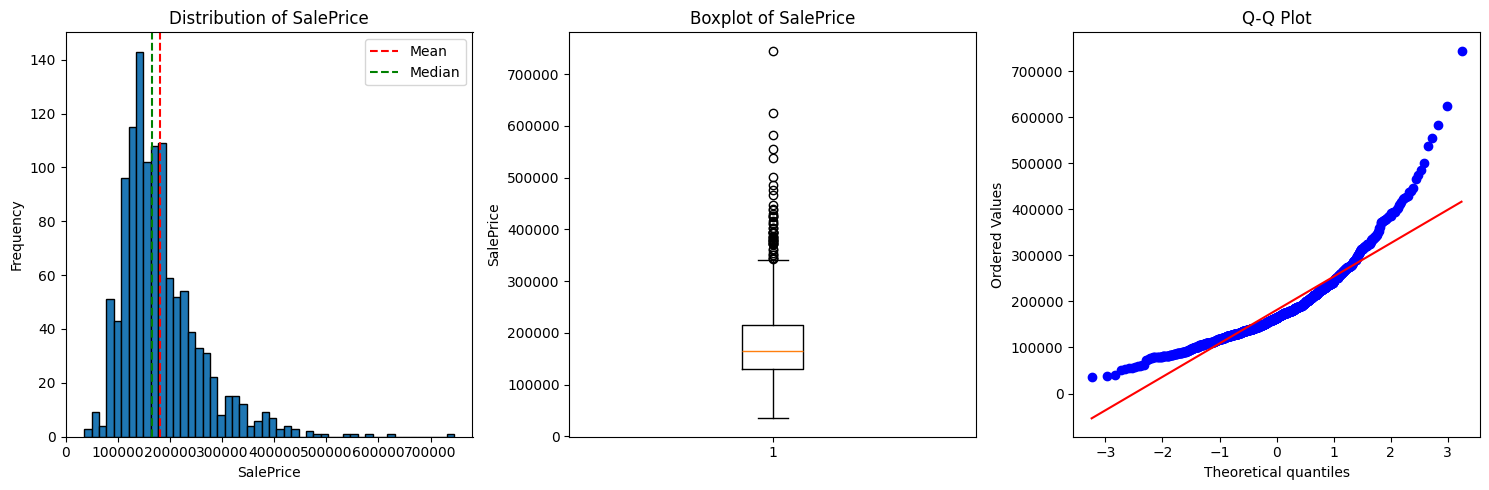

СТАТИСТИКА ЦЕН
Количество образцов: 1168
Среднее: $181,441.54
Медиана: $165,000.00
Стандартное отклонение: $77,263.58
Минимум: $34,900.00
Максимум: $745,000.00
Квартиль 1: $130,000.00
Квартиль 3: $214,925.00
IQR: $84,925.00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Анализ распределения цен
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(y_train_original, bins=50, edgecolor='black')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.axvline(y_train_original.mean(), color='r', linestyle='--', label='Mean')
plt.axvline(y_train_original.median(), color='g', linestyle='--', label='Median')
plt.legend()

plt.subplot(1, 3, 2)
plt.boxplot(y_train_original)
plt.ylabel('SalePrice')
plt.title('Boxplot of SalePrice')

plt.subplot(1, 3, 3)
stats.probplot(y_train_original, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Статистика
print("=" * 60)
print("СТАТИСТИКА ЦЕН")
print("=" * 60)
print(f"Количество образцов: {len(y_train_original)}")
print(f"Среднее: ${y_train_original.mean():,.2f}")
print(f"Медиана: ${y_train_original.median():,.2f}")
print(f"Стандартное отклонение: ${y_train_original.std():,.2f}")
print(f"Минимум: ${y_train_original.min():,.2f}")
print(f"Максимум: ${y_train_original.max():,.2f}")
print(f"Квартиль 1: ${y_train_original.quantile(0.25):,.2f}")
print(f"Квартиль 3: ${y_train_original.quantile(0.75):,.2f}")
print(f"IQR: ${y_train_original.quantile(0.75) - y_train_original.quantile(0.25):,.2f}")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ваши данные
y_train_original = pd.Series(y_train_original)  # если еще не в формате Series

print("=" * 60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ")
print("=" * 60)

# Расчет границ для разных методов
Q1 = 130000
Q3 = 214925
IQR = 84925

# IQR метод (1.5x)
lower_iqr_15 = Q1 - 1.5 * IQR
upper_iqr_15 = Q3 + 1.5 * IQR

# IQR метод (3x) - более мягкий
lower_iqr_3 = Q1 - 3 * IQR
upper_iqr_3 = Q3 + 3 * IQR

print(f"\nГраницы по IQR (1.5x):")
print(f"  Нижняя: ${lower_iqr_15:,.2f}")
print(f"  Верхняя: ${upper_iqr_15:,.2f}")

print(f"\nГраницы по IQR (3x):")
print(f"  Нижняя: ${lower_iqr_3:,.2f}")
print(f"  Верхняя: ${upper_iqr_3:,.2f}")

# Находим выбросы
outliers_15 = (y_train_original < lower_iqr_15) | (y_train_original > upper_iqr_15)
outliers_3 = (y_train_original < lower_iqr_3) | (y_train_original > upper_iqr_3)

print(f"\nКоличество выбросов:")
print(f"  IQR 1.5x: {outliers_15.sum()} ({100*outliers_15.sum()/len(y_train_original):.1f}%)")
print(f"  IQR 3x: {outliers_3.sum()} ({100*outliers_3.sum()/len(y_train_original):.1f}%)")

# Показываем выбросы
print(f"\nВыбросы по IQR 1.5x (цены выше ${upper_iqr_15:,.0f}):")
high_outliers = y_train_original[y_train_original > upper_iqr_15].sort_values()
print(high_outliers.to_string())

print(f"\nВыбросы по IQR 1.5x (цены ниже ${lower_iqr_15:,.0f}):")
low_outliers = y_train_original[y_train_original < lower_iqr_15].sort_values()
print(low_outliers.to_string())

ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ

Границы по IQR (1.5x):
  Нижняя: $2,612.50
  Верхняя: $342,312.50

Границы по IQR (3x):
  Нижняя: $-124,775.00
  Верхняя: $469,700.00

Количество выбросов:
  IQR 1.5x: 48 (4.1%)
  IQR 3x: 8 (0.7%)

Выбросы по IQR 1.5x (цены выше $342,312):
320     342643.0
11      345000.0
642     345000.0
654     350000.0
877     350000.0
321     354000.0
608     359100.0
702     361919.0
644     370878.0
151     372402.0
678     372500.0
481     374000.0
313     375000.0
336     377426.0
1388    377500.0
1267    378500.0
477     380000.0
1268    381000.0
112     383970.0
825     385000.0
53      385000.0
224     386250.0
688     392000.0
1181    392500.0
378     394432.0
1437    394617.0
987     395192.0
661     402000.0
515     402861.0
1353    410000.0
161     412500.0
278     415298.0
664     423000.0
1142    424870.0
389     426000.0
496     430000.0
349     437154.0
473     440000.0
527     446261.0
1373    466500.0
185     475000.0
798     485000.0
178     501837.0
76

In [ ]:
df[df['SalePrice'] < 469700]

InvalidIndexError: (0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: SalePrice, Length: 1460, dtype: bool, 700)